In [205]:
import pandas as pd
import numpy as np
import seaborn as sb
import math
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d


In [106]:
set_config(transform_output="pandas")

train_data = pd.read_csv("./dataset/train.csv")
test_data = pd.read_csv("./dataset/test.csv")


# Inspect Data

In [107]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [108]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [164]:
# Get an understanding of the data within each column >> View as scrollable element
for col_name, data in train_data.items():
    print(f"{col_name}: {pd.unique(data)}")

PassengerId: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 2

In [178]:
# Selected purely by "hunch", later will run another experiment better determine features
features = ["Age", "Sex", "Pclass"]

train_data_copy[features].isna().sum()

Age       0
Sex       0
Pclass    0
dtype: int64

# Clean/Preprocess Data

### Missing Data

1. Age has a lot of missing data based on the count from above. `.dropna` is my first approach to handling missing data which is the easiest to get started with. UPDATE - This is not valid as the submission requires all the rows to be present
2. Instead I will impute using mean base on this [Geeks for Geeks Article](https://www.geeksforgeeks.org/data-analysis/handling-missing-values-machine-learning/)

### Label Encoding

I plan on using sex predictor variable in my model to I assign each category with an integer. 



In [110]:
train_data_copy = train_data.copy()
train_data_copy.fillna({"Age": train_data_copy["Age"].mean()}, inplace=True)

train_data_copy["Sex"] = train_data_copy["Sex"].replace({
    "male" : 0,
    "female" : 1
})

test_data_copy = test_data.copy()
test_data_copy.fillna({"Age": test_data_copy["Age"].mean()}, inplace=True)
test_data_copy["Sex"] = test_data_copy["Sex"].replace({
    "male" : 0,
    "female" : 1
})


In [111]:
features = ["Age", "Sex", "Pclass"]

train_data_copy[features].isna().sum()

Age       0
Sex       0
Pclass    0
dtype: int64

# Scale Data

I am going to use KNN to make predictions. I need to scale it since the model uses distance calculations based on the predictor variables, scaling it ensures that the calcution isn't biased towards any one predictor variable with a large scale.

In [112]:
scaler = StandardScaler()

train_data_copy[features] = scaler.fit_transform(train_data_copy[features])
test_data_copy[features] = scaler.fit_transform(test_data_copy[features])


# Visualize Training Data

<module 'matplotlib.pyplot' from '/Users/stevenhan/Documents/Learning/Data Science Foundations/Github/learn-predict-repeat/my_virtual_env/lib/python3.13/site-packages/matplotlib/pyplot.py'>

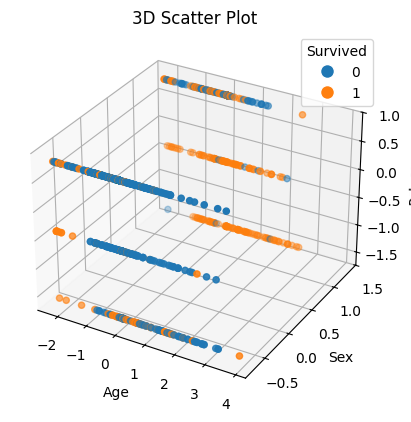

In [113]:
# Create mapping between values and colors
labels = train_data_copy["Survived"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(train_data_copy['Age'], train_data_copy['Sex'], train_data_copy['Pclass'], 
                  c=train_data_copy['Survived'].map(color_map), marker='o')

# Add axis labels
ax.set_xlabel('Age')
ax.set_ylabel('Sex')
ax.set_zlabel('Pclass')
ax.set_title('3D Scatter Plot')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add legend
plt.legend(handles=handles, title='Survived')

# Show plot
plt


# Run K-Nearest Neighbor Classifier

This data set does not provide the test response variable so I won't be able to optimize for the hyper parameter `n_nieghbors`. I can do this manually — run, check, adjust, repeat. Which is exactly what I ended up doing.

| n_neighbors | Score |
| --- | --- |
| 5 | 0.73205 |
| 7 | 0.73923 |
| 9 | 0.75119 |
| 11 | 0.74641 |

This shows 9 n_neighbors has the best result but this score is lower than the gendered_submission — from the [tutorial by Alexis](https://www.kaggle.com/code/alexisbcook/titanic-tutorial) — which scored 0.77511

In [ ]:
knn = KNeighborsClassifier(n_neighbors= 9)

X_train = train_data_copy[features]
y_train = train_data_copy["Survived"]

knn.fit(X=X_train, y=y_train)
test_data_copy["Predicted"] = knn.predict(test_data_copy[features])



In [115]:
output = pd.DataFrame({'PassengerId': test_data_copy.PassengerId, 'Survived': test_data_copy.Predicted})
output.to_csv('submission.csv', index=False)

# Visualize Predicted Test Data

<module 'matplotlib.pyplot' from '/Users/stevenhan/Documents/Learning/Data Science Foundations/Github/learn-predict-repeat/my_virtual_env/lib/python3.13/site-packages/matplotlib/pyplot.py'>

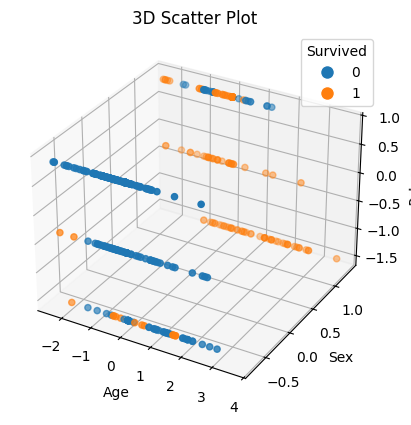

In [116]:
# Create mapping between values and colors
labels = test_data_copy["Predicted"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(test_data_copy['Age'], test_data_copy['Sex'], test_data_copy['Pclass'], 
                  c=test_data_copy['Predicted'].map(color_map), marker='o')

# Add axis labels
ax.set_xlabel('Age')
ax.set_ylabel('Sex')
ax.set_zlabel('Pclass')
ax.set_title('3D Scatter Plot')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add legend
plt.legend(handles=handles, title='Survived')

# Show plot
plt


# V2 - Feature Engineering

Using Age, Sex, Pclass as the initial features provided as easy start but now I'd like to dive deeper and see if I can include the other remaining predictor variables or feature engineer some new ones.

In [197]:
train_data_copy['Title'] = train_data_copy['Name'].str.extract(' ([A-Za-z]+).', expand=False)
train_data_copy['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
train_data_copy['IsAlone'] = (train_data_copy['FamilySize'] == 1).astype(int)
train_data_copy['FareBin'] = pd.qcut(train_data_copy['Fare'], 4, labels=[1, 2, 3, 4])
train_data_copy['CabinLetter'] = train_data_copy['Cabin'].astype(str).str[0]


for col_name, data in train_data_copy[['Title', 'FamilySize', 'IsAlone', 'FareBin', 'CabinLetter']].items():
    print(f"{col_name}: {pd.unique(data)}")

Title: <StringArray>
[         'Mr',         'Mrs',        'Miss',      'Master',      'Planke',
         'Don',         'Rev',    'Billiard',         'der',       'Walle',
          'Dr',  'Pelsmaeker',      'Mulder',           'y',       'Steen',
       'Carlo',         'Mme',        'Impe',          'Ms',       'Major',
      'Gordon', 'Messemaeker',        'Mlle',         'Col',        'Capt',
       'Velde',         'the',      'Shawah',    'Jonkheer',   'Melkebeke',
    'Cruyssen']
Length: 31, dtype: str
FamilySize: [ 2  1  5  3  7  6  4  8 11]
IsAlone: [0 1]
FareBin: [1, 4, 2, 3]
Categories (4, int64): [1 < 2 < 3 < 4]
CabinLetter: <StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str


### Visualize each column vs 'survived'



In [231]:
family = train_data_copy[["FamilySize", "Survived"]].groupby(['FamilySize']).value_counts()
family

FamilySize  Survived
1           0           374
            1           163
2           1            89
            0            72
3           1            59
            0            43
4           1            21
            0             8
5           0            12
            1             3
6           0            19
            1             3
7           0             8
            1             4
8           0             6
11          0             7
Name: count, dtype: int64

I am trying to loop through each feature and plot the unique values against the surivived column. I am trying to get the sub index "Surived" as the hue. the X axis as the unique values and the Y axis the valuecount.

In [ ]:
col_not_to_include = ['PassengerId', 'Name', 'Survived']
# length of col - length col not to include / 2

num_rows = math.floor((train_data_copy.shape[1] - len(col_not_to_include))/2 + 1)
# fig, axes = plt.subplots(num_rows, 2)

x = 
sb.barplot(data=train_data_copy, x=train_data_copy["FamilySize"], y=family.values)
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.